In [ ]:
import pandas as pd
import sklearn as sk
import os
import torch.optim as optim
from sklearn.metrics import mean_squared_error,mean_absolute_error
from sklearn.model_selection import train_test_split
import myConfig
os.chdir(myConfig.absPath)
import numpy as np
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import math
import matplotlib.pyplot as plt
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


In [2]:
dataset = pd.read_csv("data\\StudentPerformanceFactors_prepared.csv")
dataset

,Gender_Male,Gender_Female,Learning_Disabilities_Yes,Learning_Disabilities_No,Distance_from_Home_Near,Distance_from_Home_Moderate,Distance_from_Home_Far,Parental_Education_Level_Postgraduate,Parental_Education_Level_High School,Parental_Education_Level_College,...,Parental_Involvement_Medium,Parental_Involvement_Low,Parental_Involvement_High,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,19,88,8,89,3,3,71
1,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,29,84,7,68,1,2,67
2,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,...,0.0,1.0,0.0,25,78,6,50,1,2,66
3,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,0.0,17,94,6,80,0,1,69
4,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,23,98,8,71,0,5,72
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6368,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,25,69,7,76,1,2,68
6369,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,23,76,8,81,3,2,69
6370,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,20,90,6,65,3,2,68
6371,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,1.0,10,86,6,91,2,3,68


In [3]:
features = dataset.columns.to_list()
features.remove("Exam_Score")
X_train, X_test, y_train, y_test = train_test_split(dataset[features], dataset["Exam_Score"], test_size=0.3, random_state=myConfig.random_state)
X_train, X_test,y_train,y_test  = X_train.to_numpy(), X_test.to_numpy(),y_train.to_numpy(),y_test.to_numpy()

In [4]:
class MLP(nn.Module):
    def __init__(
        self    ):
        super().__init__()

        layers= [#nn.Flatten(),
    nn.Linear(X_train.shape[1],80),
    nn.Tanh(),
    nn.Dropout(p=0.02),
    nn.Linear(80,80),
    nn.Tanh(),
    nn.Dropout(p=0.02),
    nn.Linear(80,80),
    nn.LeakyReLU(),
    nn.Dropout(p=0.02),
    nn.Linear(80,55),
    nn.Dropout(p=0.02),
    nn.Linear(55,15),
    nn.LeakyReLU(),
    nn.Linear(15,1),
    #nn.ReLU()
]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

In [5]:
def accuracy_from_logits(logits: torch.Tensor, y_true: torch.Tensor) -> float:
    # Accuracy для классификации: logits -> argmax -> сравнение с y_true.
    #preds = torch.argmax(logits,dim=0)
    #print( logits)
    return 1-abs(y_true.detach().numpy()[0]-logits.detach().numpy()[0])/100 #r2_score(y_true.detach().numpy(),logits.detach().numpy())
def train_one_epoch(model, x,y, optimizer, criterion, device):
    model.train()  # включаем train-режим (Dropout/BatchNorm!)
    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0

    for i in range(len(x)):
       x_i = torch.Tensor( x[i]).to(device, non_blocking=True)
       
       y_i = torch.Tensor([y[i]]).to(device, non_blocking=True)
       optimizer.zero_grad(set_to_none=True)
       logits = model(x_i)
       
       loss = criterion(logits, y_i)
       loss.backward()
       optimizer.step()
       total_loss += loss.item()
       total_acc += accuracy_from_logits(logits, y_i)
       n_batches += 1
    return total_loss / n_batches, total_acc / n_batches

@torch.no_grad()
def evaluate(model, x,y, criterion, device):
    model.eval()  # включаем eval-режим (Dropout/BatchNorm!)
    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0

    for i in range(len(x)):
        x_i = torch.Tensor( x[i]).to(device, non_blocking=True)
       
        y_i = torch.Tensor([y[i]]).to(device, non_blocking=True)

        logits = model(x_i)
        loss = criterion(logits, y_i)

        total_loss += loss.item()
        total_acc += accuracy_from_logits(logits, y_i)
        n_batches += 1

    return total_loss / n_batches, total_acc / n_batches

def fit(
    model,
    x_train,y_train,
    x_val,y_val,
    optimizer,
    criterion,
    device,
    epochs: int = 20,
    early_stopping=None,
    verbose: bool = True,
):
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, x_train,y_train, optimizer, criterion, device)
        va_loss, va_acc = evaluate(model, x_val,y_val, criterion, device)

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)

        if verbose:
            print(
                f"epoch {epoch:02d}/{epochs} | "
                f"train loss={tr_loss:.4f}, acc={tr_acc:.4f} | "
                f"val loss={va_loss:.4f}, acc={va_acc:.4f}"
            )

        if early_stopping is not None:
            should_stop = early_stopping.step(va_acc, model)
            if should_stop:
                if verbose:
                    print(
                        f"EarlyStopping: остановка на эпохе {epoch}. "
                        f"Лучший val_acc={early_stopping.best_score:.4f}"
                    )
                early_stopping.restore_best(model)
                break

    return history
def regression_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    """
    Вычисляет три основные метрики для регрессии:
    - MAE (Mean Absolute Error): средняя абсолютная ошибка в исходном масштабе
    - RMSE (Root Mean Squared Error): корень из среднеквадратичной ошибки
    - MAPE (Mean Absolute Percentage Error): средняя абсолютная процентная ошибка (%)
    """
    mae = mean_absolute_error(y_true, y_pred)
    rmse = math.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / np.clip(np.abs(y_true), 1e-8, None))) * 100
    return {"MAE": mae, "RMSE": rmse, "MAPE": mape}


In [6]:
model = MLP().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()
#train_one_epoch(model,X_train,y_train,optimizer,criterion,device)
#plot_history(history, title="E1")
#model.fit(X_train,y_train)

In [7]:
history= fit(
    model, X_train,y_train, X_test,y_test,
    optimizer, criterion, device,
    epochs=20,
    early_stopping=None
)

epoch 01/20 | train loss=61.1270, acc=0.9573 | val loss=13.0855, acc=0.9766
epoch 02/20 | train loss=19.3307, acc=0.9671 | val loss=10.4576, acc=0.9809
epoch 03/20 | train loss=18.1409, acc=0.9684 | val loss=13.2626, acc=0.9755
epoch 04/20 | train loss=17.0495, acc=0.9698 | val loss=7.4876, acc=0.9862
epoch 05/20 | train loss=15.4151, acc=0.9718 | val loss=9.7169, acc=0.9810
epoch 06/20 | train loss=15.2002, acc=0.9719 | val loss=6.5119, acc=0.9888
epoch 07/20 | train loss=14.5141, acc=0.9727 | val loss=12.5412, acc=0.9742
epoch 08/20 | train loss=14.1500, acc=0.9731 | val loss=18.0494, acc=0.9654
epoch 09/20 | train loss=14.0010, acc=0.9734 | val loss=6.4649, acc=0.9907
epoch 10/20 | train loss=13.2604, acc=0.9744 | val loss=7.0383, acc=0.9883
epoch 11/20 | train loss=12.9783, acc=0.9746 | val loss=6.6013, acc=0.9885
epoch 12/20 | train loss=12.5680, acc=0.9753 | val loss=12.7114, acc=0.9741
epoch 13/20 | train loss=12.6615, acc=0.9753 | val loss=6.4451, acc=0.9899
epoch 14/20 | train

In [8]:
y_pred =  model(torch.Tensor(X_test))
regression_metrics(y_test,y_pred.detach().numpy())

{'MAE': 1.4081130027770996,
 'RMSE': 2.791117704325311,
 'MAPE': np.float64(5.7353820546054095)}

In [9]:
y_pred

tensor([[67.6763],
        [70.3378],
        [66.6289],
        ...,
        [66.5718],
        [68.1386],
        [64.3447]], grad_fn=<AddmmBackward0>)

In [10]:
y_test

array([69, 73, 68, ..., 68, 69, 65], shape=(1912,))

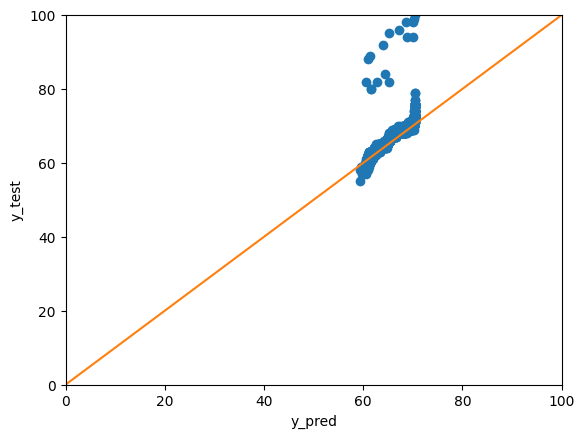

In [11]:
plt.plot(y_pred.detach().numpy(),y_test,"o")
plt.xlabel("y_pred")
plt.ylabel("y_test")
plt.xlim((0,100))
plt.ylim((0,100))
plt.plot((0,100),(0,100))
plt.show()

Из экспериментов (`model_experiments.ipynb` , `model_experiments2.ipynb` и `baseline_training.ipynb`) следует, что усложненние модели не увеличивает её точность, соответственно нерационально использовать полноценную нейронную сеть в сервисе по соотношению результат/количество вычислений.